<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/03_Level_2_Functional_Spectral_Uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Level 2: Functional Spectral Uncertainty

Level 2 removes the requirement to describe each endmember by named peak parameters.

Instead, prior spectral knowledge is supplied as an ensemble of plausible complete spectra:

`S_library[k, realization, channel]`

For each component, the package constructs a reduced representation in log-spectrum space. Functional coefficients are inferred jointly with the local concentrations/fractions.

The uncertainty is therefore uncertainty in **complete correlated spectral functions**, not independent error bars at every spectral channel.

In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


In [2]:
data = pu.generate_example(
    n_locations=40,
    n_channels=120,
    n_library=100,
    seed=42,
)

print("Level 2 library shape:", data.S_library.shape)

Level 2 library shape: (4, 100, 120)


## Inspect the functional library

Each faint line below is one complete plausible spectrum. The spread is structured because peak position, width, and relative area vary coherently.

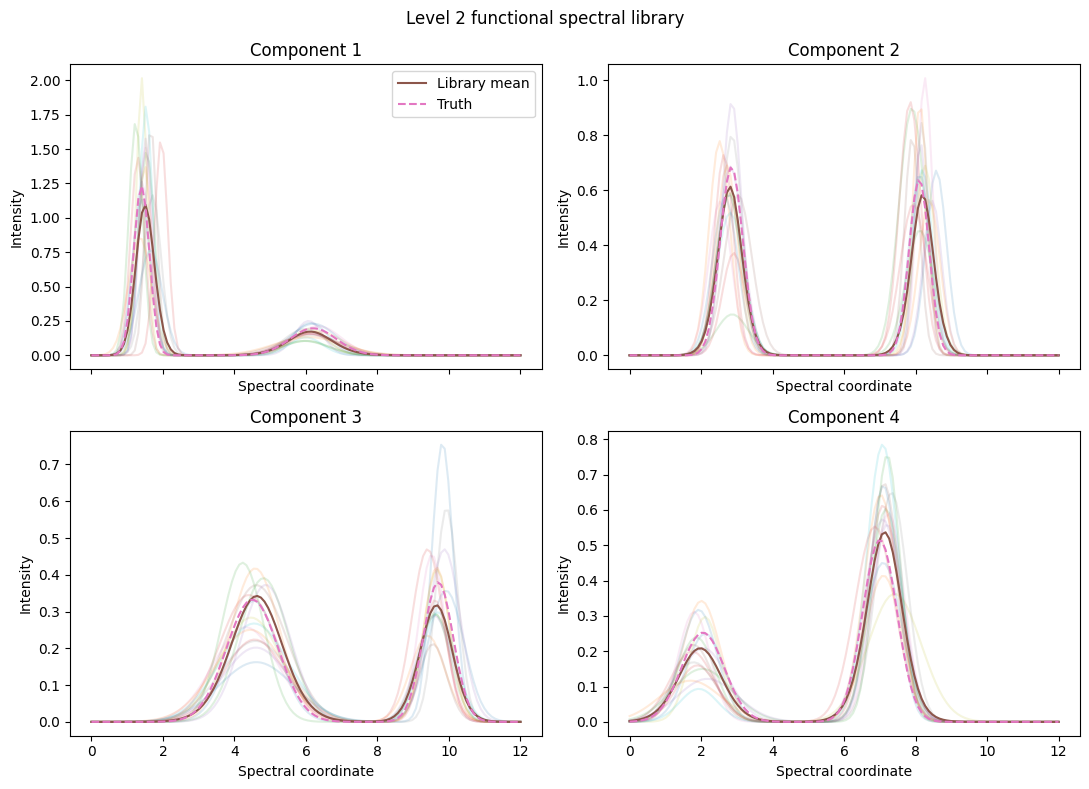

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.ravel()

for k, ax in enumerate(axes):
    library = data.S_library[k]
    for j in range(min(15, library.shape[0])):
        ax.plot(data.E, library[j], alpha=0.15)
    ax.plot(data.E, library.mean(axis=0), label="Library mean")
    ax.plot(data.E, data.S_true[k], "--", label="Truth")
    ax.set_title(f"Component {k+1}")
    ax.set_xlabel("Spectral coordinate")
    ax.set_ylabel("Intensity")

axes[0].legend()
fig.suptitle("Level 2 functional spectral library")
fig.tight_layout();

## Fit Level 2

The first package implementation uses joint MAP estimation followed by a Gaussian/Laplace approximation to propagate uncertainty.

In [4]:
result2 = pu.fit(
    data,
    level=2,
    n_draws=800,
    seed=102,
    max_nfev=250,
)

print(result2.metrics)
print()
print("Retained functional ranks:", result2.metadata["ranks"])
print("Explained log-library variance:", result2.metadata["explained_variance"])

{'reconstruction_rmse': 0.010223980237130031, 'mean_concentration_sd': 0.00596275894575329, 'mean_spectral_sd': 0.0011288971355001662, 'n_functional_parameters': 43, 'n_total_parameters': 163, 'optimizer_cost': 2387.908509436581, 'optimizer_nfev': 49, 'concentration_rmse': 0.005887022071908002, 'spectral_rmse': 0.0012873030858813392}

Retained functional ranks: [12, 12, 10, 9]
Explained log-library variance: [0.9956931387459695, 0.9894428847111739, 0.9971295533913249, 0.9950116257747551]


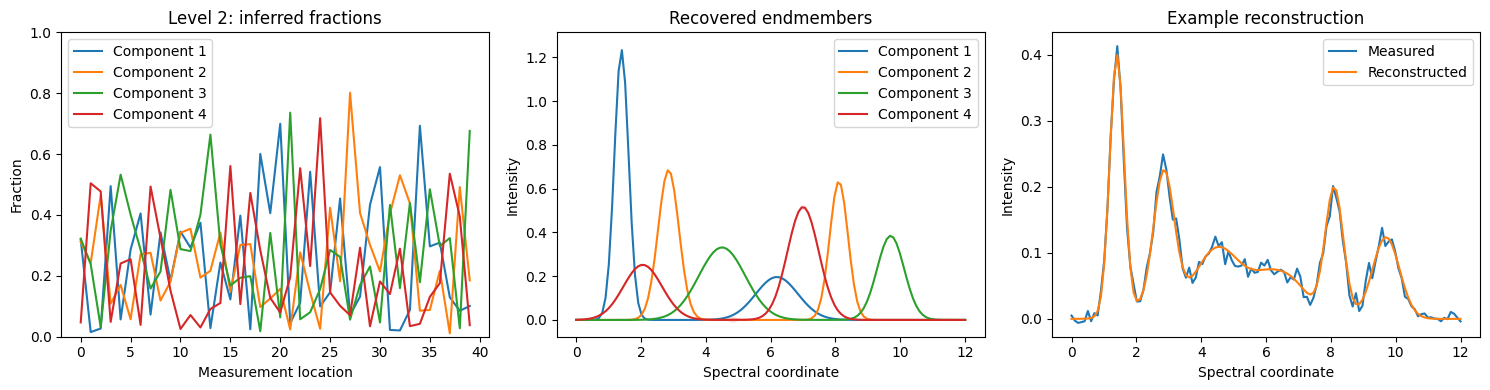

In [5]:
pu.plot_result(data, result2);

## Mathematical sanity checks

The recovered fractions should remain on the simplex and every recovered endmember should remain positive and normalized to unit integrated area.

In [6]:
print("Maximum fraction closure error:",
      np.abs(result2.W_mean.sum(axis=1) - 1).max())

print("Minimum recovered intensity:", result2.S_mean.min())

areas = np.trapz(result2.S_mean, data.E, axis=1)
print("Recovered endmember areas:", areas)

Maximum fraction closure error: 8.881784197001252e-16
Minimum recovered intensity: 1.0644655720839717e-08
Recovered endmember areas: [1. 1. 1. 1.]


/tmp/ipykernel_808/2942192281.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  areas = np.trapz(result2.S_mean, data.E, axis=1)


**Takeaway:** Level 2 is appropriate when spectral prior knowledge is naturally available as measured or simulated ensembles rather than as a small set of named line-shape parameters.